# Module 7 - Notebook Giám sát Mô hình

Notebook này triển khai luồng monitoring cho mô hình fraud đã deploy:

- Theo dõi data drift giữa tập reference và current
- Theo dõi precision/recall/F1 trên rolling window
- Tạo dashboard Evidently
- Đánh giá retraining triggers

In [35]:
# Đảm bảo các thư viện monitoring đã sẵn sàng cho kernel notebook hiện tại.
import subprocess
import sys

packages = [
    'evidently>=0.7,<0.8',
    'pydantic>=2.10',
    'scipy>=1.10',
    'scikit-learn>=1.3',
    'joblib>=1.3',
    'pyarrow>=14.0',
    'tabulate>=0.9.0',
]

print('Đang cài đặt/nâng cấp các dependency monitoring cho kernel này...')
subprocess.check_call([
    sys.executable,
    '-m',
    'pip',
    'install',
    '--upgrade',
    '--user',
    *packages,
])
print('Thiết lập dependency hoàn tất.')

Đang cài đặt/nâng cấp các dependency monitoring cho kernel này...
Thiết lập dependency hoàn tất.


In [36]:
from pathlib import Path
import sys
import json
import importlib
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'models').exists() and (p / 'Module_07').exists():
            return p
    raise RuntimeError('Không thể xác định thư mục gốc của repo')

ROOT = find_repo_root(Path.cwd())
module7_path = ROOT / 'Module_07'

# Đưa Module_07 lên đầu sys.path để tránh import nhầm package 'monitoring' từ môi trường.
if str(module7_path) in sys.path:
    sys.path.remove(str(module7_path))
sys.path.insert(0, str(module7_path))

import monitoring as mon
mon = importlib.reload(mon)

print('ROOT =', ROOT)
print('Monitoring script =', ROOT / 'Module_07' / 'monitoring.py')
print('Đã import monitoring từ:', Path(mon.__file__).resolve())

ROOT = d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust
Monitoring script = d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\monitoring.py
Đã import monitoring từ: D:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\monitoring.py


## 1) Cấu hình và artifact

Notebook dùng lại artifact đã có trong repo:

- `models/best_model.joblib`
- `models/decision_threshold.json`
- `models/feature_list.json`
- `data/processed/transactions_enriched.parquet`

In [37]:
ENRICHED = ROOT / 'data' / 'processed' / 'transactions_enriched.parquet'
MODEL = ROOT / 'models' / 'best_model.joblib'
POLICY = ROOT / 'models' / 'decision_threshold.json'
FEATURES = ROOT / 'models' / 'feature_list.json'
EVENTS_LOG = ROOT / 'Module_07' / 'inputs' / 'module6_scored_events.jsonl'
OUTPUT_DIR = ROOT / 'Module_07' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model, policy, meta, deployed_features = mon.load_artifacts(MODEL, POLICY, FEATURES)
threshold = float(policy['threshold'])

print('Model type:', type(model).__name__)
print('Threshold:', threshold)
print('Number of deployed features:', len(deployed_features))
print('First 10 features:', deployed_features[:10])
print('Module 6 events log:', EVENTS_LOG)
print('Events log exists:', EVENTS_LOG.exists())

Model type: RandomForestClassifier
Threshold: 0.004
Number of deployed features: 37
First 10 features: ['step', 'account_age_days', 'is_new_device', 'shipping_billing_mismatch', 'failed_payment_attempts', 'ip_billing_distance_km', 'is_night', 'ip_country_mismatch', 'log_ip_distance', 'young_account']
Module 6 events log: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\inputs\module6_scored_events.jsonl
Events log exists: True


## 2) Score các giao dịch hiện tại

Bước này rebuild bộ feature hành vi từ enriched data, sau đó score bằng model deploy.

In [38]:
monitored = mon.score_monitoring_frame(
    enriched_path=ENRICHED,
    model=model,
    deployed_features=deployed_features,
    threshold=threshold,
)

reference, historical_current = mon.split_reference_current(monitored, reference_max_step=354)

events_current = mon.build_monitoring_frame_from_module6_events(
    events_log_path=EVENTS_LOG,
    model=model,
    deployed_features=deployed_features,
    threshold=threshold,
)

if len(events_current):
    current = events_current
    current_source = 'module6_events'
else:
    current = historical_current
    current_source = 'historical_enriched'

print('Current source:', current_source)
print('Monitored shape (historical full):', monitored.shape)
print('Reference rows:', len(reference))
print('Current rows:', len(current))

display(current[['step', 'target', 'prediction', 'prediction_proba']].head())

Current source: module6_events
Monitored shape (historical full): (2770409, 41)
Reference rows: 2217905
Current rows: 47


,step,target,prediction,prediction_proba
4,745,NaN,1,0.416927
7,746,NaN,1,0.398099
9,746,NaN,1,0.814491
10,746,NaN,1,0.642741
13,747,NaN,1,0.409549


## 3) Giám sát data drift

Sử dụng KS cho numerical features và Chi-square cho binary features.

In [39]:
drift_summary = mon.compute_drift_summary(reference, current, deployed_features, alpha=0.05)
drift_path = OUTPUT_DIR / 'drift_summary.csv'
drift_summary.to_csv(drift_path, index=False)

drift_fraction = float(drift_summary['drifted'].mean()) if len(drift_summary) else 0.0
print('Drifted features:', int(drift_summary['drifted'].sum()), '/', len(drift_summary))
print('Drift fraction:', round(drift_fraction, 4))
print('Saved:', drift_path)

display(drift_summary.head(15))

Drifted features: 13 / 37
Drift fraction: 0.3514
Saved: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\drift_summary.csv


,feature,method,score,p_value,reference_mean,current_mean,drifted
0,step,ks_numeric,1.000000,0.000000e+00,193.475397,754.361702,True
11,dest_prior_count,ks_numeric,0.732379,2.746894e-26,5.267365,0.085106,True
12,dest_steps_since_last,ks_numeric,0.732379,2.746894e-26,20.184848,-0.425532,True
13,dest_first_seen,chi2_binary,0.732379,1.456130e-37,0.182515,0.914894,True
14,hour_sin,ks_numeric,0.559290,2.227012e-14,-0.450873,0.371431,True
6,is_night,chi2_binary,0.352603,1.782144e-134,0.009099,0.361702,True
15,hour_cos,ks_numeric,0.277518,1.081998e-03,-0.368908,-0.140260,True
1,account_age_days,ks_numeric,0.246735,5.254518e-03,359.248194,261.468085,True
4,failed_payment_attempts,ks_numeric,0.207959,2.922955e-02,0.303539,0.765957,True
9,young_account,chi2_binary,0.141825,1.881291e-03,0.092217,0.234043,True


## 4) Rolling performance metrics

Mặc định dùng rolling window 168 step (7 ngày, vì 1 step = 1 giờ trong PaySim).

In [40]:
rolling = mon.rolling_classification_metrics(current, window_steps=168)
rolling_path = OUTPUT_DIR / 'rolling_metrics.csv'
rolling.to_csv(rolling_path, index=False)

print('Rolling rows:', len(rolling))
print('Saved:', rolling_path)
display(rolling.tail(10))

Rolling rows: 2
Saved: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\rolling_metrics.csv


,window_start_step,window_end_step,n_transactions,n_fraud,n_flagged,precision,recall,f1,average_precision,fraud_rate
0,633,800,1,1,1,1.0,1.0,1.000000,NaN,1.0
1,634,801,2,1,2,0.5,1.0,0.666667,1.0,0.5


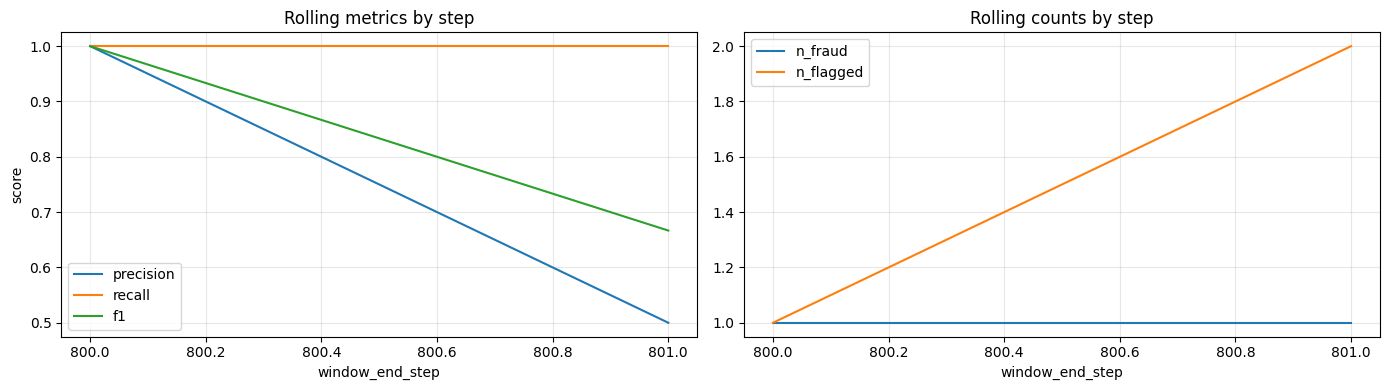

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rolling['window_end_step'], rolling['precision'], label='precision')
axes[0].plot(rolling['window_end_step'], rolling['recall'], label='recall')
axes[0].plot(rolling['window_end_step'], rolling['f1'], label='f1')
axes[0].set_title('Rolling metrics by step')
axes[0].set_xlabel('window_end_step')
axes[0].set_ylabel('score')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rolling['window_end_step'], rolling['n_fraud'], label='n_fraud')
axes[1].plot(rolling['window_end_step'], rolling['n_flagged'], label='n_flagged')
axes[1].set_title('Rolling counts by step')
axes[1].set_xlabel('window_end_step')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Evidently dashboard

Xuất dashboard HTML để review drift và classification metrics.

In [ ]:
import warnings
import numpy as np

dashboard_path = OUTPUT_DIR / 'monitoring_dashboard.html'

# Ẩn cảnh báo RuntimeWarning từ numpy khi Evidently xử lý batch nhỏ/cột gần hằng.
old_err = np.seterr(invalid='ignore', divide='ignore')
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='invalid value encountered in divide', category=RuntimeWarning)
    mon.build_evidently_dashboard(
        reference=reference,
        current=current,
        features=deployed_features,
        output_path=dashboard_path,
        max_rows=50000,
    )
np.seterr(**old_err)

print('Đã lưu dashboard:', dashboard_path)

## 6) Retraining triggers

Áp dụng trigger rule cơ bản:

- Drift fraction > 30%
- Precision < 70% baseline deployment
- Recall giảm > 15 điểm phần trăm so với baseline

In [43]:
trigger_summary = mon.evaluate_triggers(
    drift_summary=drift_summary,
    rolling_metrics=rolling,
    baseline_metrics=policy['metrics_at_threshold'],
    config=mon.TriggerConfig(),
)

trigger_path = OUTPUT_DIR / 'trigger_summary.json'
trigger_path.write_text(json.dumps(trigger_summary, indent=2, default=float), encoding='utf-8')

summary_md = OUTPUT_DIR / 'monitor_summary.md'
mon.write_summary_markdown(
    output_path=summary_md,
    reference=reference,
    current=current,
    drift_summary=drift_summary,
    rolling_metrics=rolling,
    trigger_summary=trigger_summary,
)

print('Should retrain:', trigger_summary['should_retrain'])
print('Saved trigger summary:', trigger_path)
print('Saved markdown summary:', summary_md)
trigger_summary

Should retrain: True
Saved trigger summary: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\trigger_summary.json
Saved markdown summary: d:\2026\SoICT_DataScience\Business_Intelligent\business-analysis-hust\Module_07\outputs\monitor_summary.md


{'baseline_metrics': {'AUC_PR': 0.866,
  'threshold*': 0.004,
  'precision': 0.0128,
  'recall': 0.9988,
  'F1': 0.0252,
  'net_cost': 4534131.0,
  'n_fp': 328519.0,
  'savings_vs_approve_all': 6698060635.0},
 'latest_window_metrics': {'window_start_step': 634.0,
  'window_end_step': 801.0,
  'n_transactions': 2.0,
  'n_fraud': 1.0,
  'n_flagged': 2.0,
  'precision': 0.5,
  'recall': 1.0,
  'f1': 0.6666666666666666,
  'average_precision': 1.0,
  'fraud_rate': 0.5},
 'has_labelled_performance': True,
 'triggers': {'drift_fraction': {'value': 0.35135135135135137,
   'threshold': 0.3,
   'breached': True},
  'precision_drop': {'value': 0.5, 'threshold': 0.00896, 'breached': False},
  'recall_drop': {'value': 1.0, 'threshold': 0.8488, 'breached': False},
  'scheduled_retrain': {'policy': 'review monthly even without drift, because fraud patterns evolve',
   'breached': False}},
 'should_retrain': True}

## 7) Kết luận cho Module 7

Checklist nộp bài:

- Có drift monitoring report (`drift_summary.csv` + Evidently HTML)
- Có performance monitoring theo rolling window (`rolling_metrics.csv`)
- Có retraining trigger policy và kết quả (`trigger_summary.json`)
- Có file tổng hợp để đọc nhanh (`monitor_summary.md`)